# Fase 2 — Visualización táctica de equipo

Módulos 3, 4, 5, 13, 14 del temario: shot maps, pass networks, heat maps de
equipo, posición media y zonas de generación/recepción de pases.

Partimos del parquet guardado en `01_scraping_fotmob_statsbomb.ipynb`. Si no
lo corriste todavía, hazlo primero.

In [2]:
import pandas as pd
from mplsoccer import Pitch
import matplotlib.pyplot as plt

events = pd.read_pickle("../data/processed/events_ejemplo.pkl")
events.shape

(3589, 80)

## Shot map

Cada tiro es un evento `type == "Shot"`. StatsBomb guarda la ubicación en la
columna `location` como `[x, y]` y el xG del tiro en `shot_statsbomb_xg`.

Text(0.5, 1.0, 'Shot map — tamaño = xG, rojo = gol')

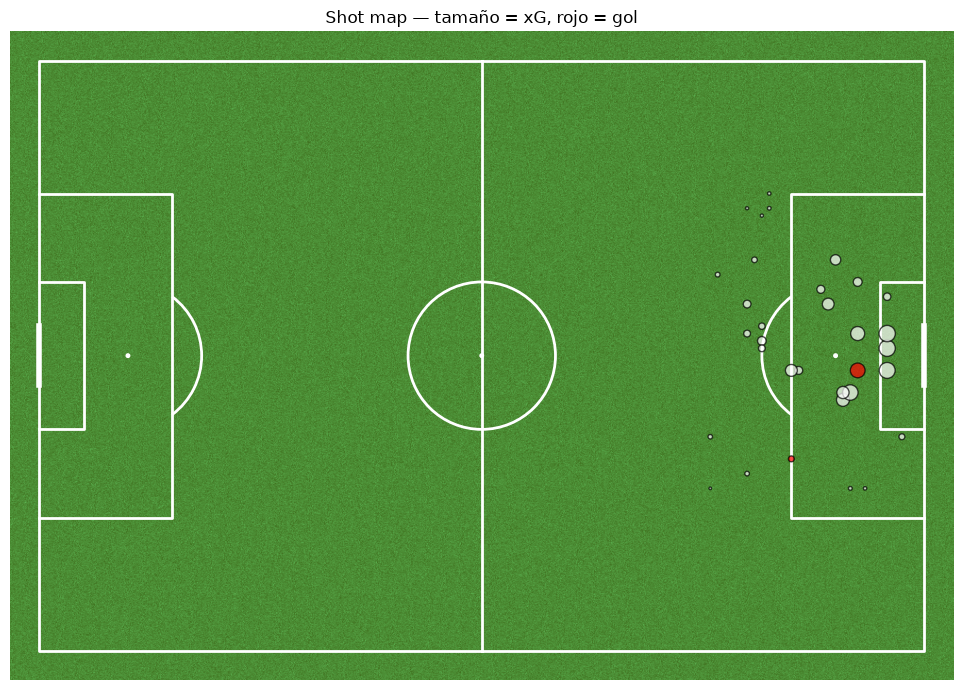

In [3]:
shots = events[events["type"] == "Shot"].copy()
shots[["x", "y"]] = pd.DataFrame(shots["location"].tolist(), index=shots.index)

pitch = Pitch(pitch_type="statsbomb", pitch_color="grass", line_color="white")
fig, ax = pitch.draw(figsize=(10, 7))

pitch.scatter(
    shots["x"], shots["y"],
    s=shots["shot_statsbomb_xg"] * 500,  # tamaño proporcional al xG
    c=shots["shot_outcome"].eq("Goal").map({True: "red", False: "white"}),
    edgecolors="black", alpha=0.7, ax=ax,
)
ax.set_title("Shot map — tamaño = xG, rojo = gol")

## Pass network

Un pass network representa a cada jugador como un nodo (posicionado en su
ubicación media de pase) y cada arista como el número de pases entre dos
jugadores. Filtramos por un solo equipo y, típicamente, sólo hasta la primera
sustitución (para que la posición media siga siendo representativa).

In [4]:
equipo = events["team"].dropna().unique()[0]  # ajusta al equipo que te interese
print("Equipos disponibles:", events["team"].dropna().unique())

passes = events[
    (events["type"] == "Pass")
    & (events["team"] == equipo)
    & (events["pass_outcome"].isna())  # solo pases completados
].copy()

passes[["x", "y"]] = pd.DataFrame(passes["location"].tolist(), index=passes.index)
passes[["end_x", "end_y"]] = pd.DataFrame(passes["pass_end_location"].tolist(), index=passes.index)
passes["receiver"] = passes["pass_recipient"]

avg_locations = passes.groupby("player").agg(x=("x", "mean"), y=("y", "mean"), num_passes=("x", "count"))
avg_locations.head()

Equipos disponibles: <StringArray>
['Brazil', 'Belgium']
Length: 2, dtype: str


,x,y,num_passes
player,,,
Alisson Ramsés Becker,11.833333,38.833333,6
Douglas Costa de Souza,79.800000,59.266667,15
Fernando Luiz Roza,55.403509,38.245614,57
Fágner Conserva Lemos,53.200000,68.285714,35
Gabriel Fernando de Jesus,93.714286,52.142857,7


Text(0.5, 1.0, 'Pass network — Brazil')

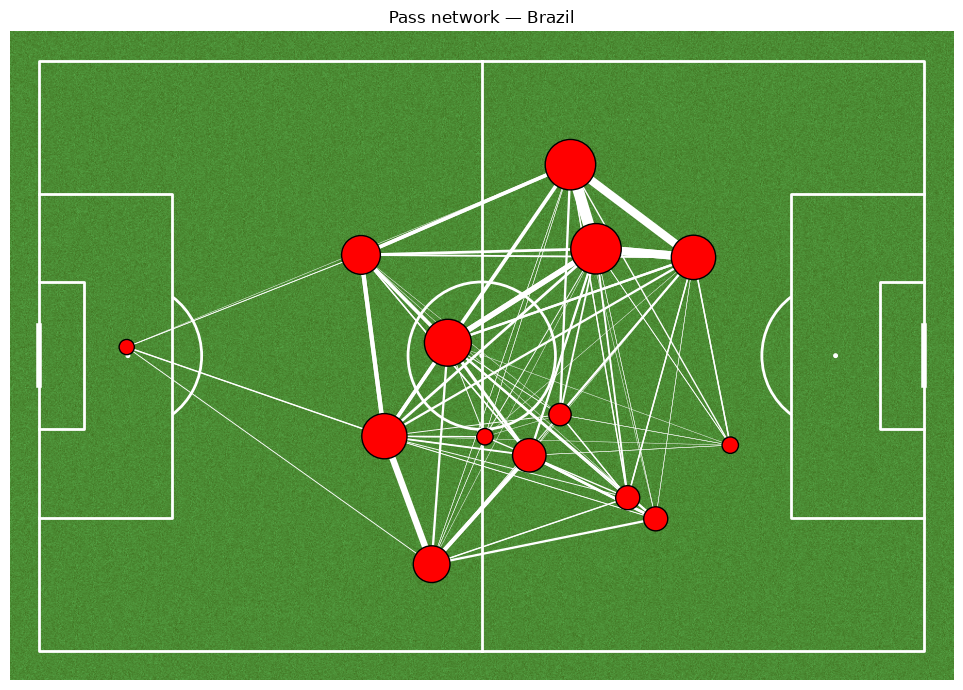

In [5]:
pass_pairs = (
    passes.groupby(["player", "receiver"]).size().reset_index(name="num_passes")
)
pass_pairs = pass_pairs.merge(
    avg_locations[["x", "y"]], left_on="player", right_index=True
).merge(
    avg_locations[["x", "y"]], left_on="receiver", right_index=True, suffixes=("", "_end")
)

pitch = Pitch(pitch_type="statsbomb", pitch_color="grass", line_color="white")
fig, ax = pitch.draw(figsize=(10, 7))

pitch.lines(
    pass_pairs.x, pass_pairs.y, pass_pairs.x_end, pass_pairs.y_end,
    lw=pass_pairs.num_passes / pass_pairs.num_passes.max() * 8,
    color="white", zorder=1, ax=ax,
)
pitch.scatter(
    avg_locations.x, avg_locations.y,
    s=avg_locations.num_passes * 20, color="red", edgecolors="black", zorder=2, ax=ax,
)
ax.set_title(f"Pass network — {equipo}")

## Heat map de equipo

Usamos todas las acciones (no solo pases) del equipo para ver dónde
concentra el juego.

Text(0.5, 1.0, 'Heat map de equipo — Brazil')

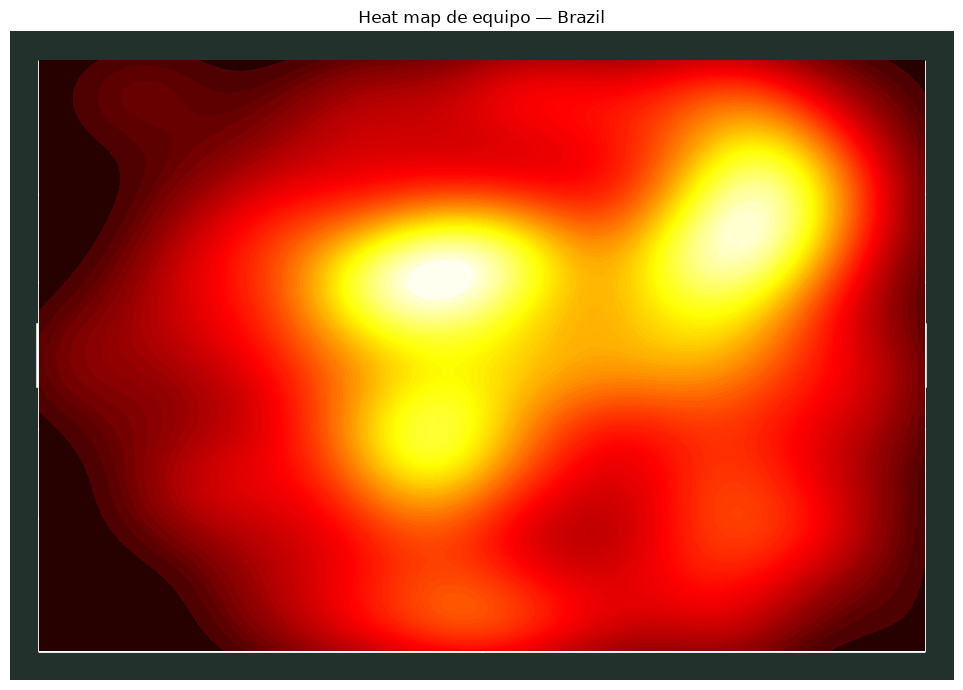

In [6]:
acciones_equipo = events[events["team"] == equipo].dropna(subset=["location"]).copy()
acciones_equipo[["x", "y"]] = pd.DataFrame(acciones_equipo["location"].tolist(), index=acciones_equipo.index)

pitch = Pitch(pitch_type="statsbomb", pitch_color="#22312b", line_color="white")
fig, ax = pitch.draw(figsize=(10, 7))
pitch.kdeplot(
    acciones_equipo.x, acciones_equipo.y, ax=ax,
    fill=True, levels=100, cmap="hot", thresh=0,
)
ax.set_title(f"Heat map de equipo — {equipo}")

## Pendiente en esta fase

- Posición media del equipo (average team position) por ventana de tiempo
  (ej. antes/después de un cambio táctico).
- Zonas de generación y recepción de pases (dividir la cancha en una grilla
  y contar pases que empiezan/terminan en cada celda — `pitch.bin_statistic`
  de mplsoccer es la herramienta natural para esto).

Siguiente notebook: `03_analisis_jugador.ipynb`.